# Data Load

In [29]:
country = "IND"

In [30]:
import os
import pandas as pd

def combine_emissions_data(root_directory, output_filename):
    """
    Finds, combines, and saves emissions data from multiple CSV files.

    Args:
        root_directory (str): The path to the main 'Data' folder.
        output_filename (str): The name for the final combined CSV file.
    """
    files_to_process = []
    
    # Step 1: Walk through the directory tree to find relevant files
    print(f"Searching for files in '{root_directory}'...")
    for dirpath, dirnames, filenames in os.walk(root_directory):
        for filename in filenames:
            # if 'emissions_sources' in filename and filename.endswith('.csv'):
            if (
                'emissions_sources' in filename 
                and filename.endswith('.csv') 
                and 'confidence' not in filename
            ):
                full_path = os.path.join(dirpath, filename)
                files_to_process.append(full_path)

    if not files_to_process:
        print("No files found matching the criteria. Please check the directory and file names.")
        return

    print(f"\nFound {len(files_to_process)} files to process:")
    for f in files_to_process:
        print(f" - {f}")

    # Step 2: Read each found CSV into a pandas DataFrame and store it in a list
    all_dataframes = []
    print("\nReading and processing files...")
    for file_path in files_to_process:
        try:
            df = pd.read_csv(file_path)
            all_dataframes.append(df)
            print(f" - Successfully read {os.path.basename(file_path)}")
        except Exception as e:
            print(f" - Could not read file {file_path}. Error: {e}")

    if not all_dataframes:
        print("No data could be read from the found files. Exiting.")
        return

    # Step 3: Concatenate all DataFrames into a single one
    print("\nCombining data into a single DataFrame...")
    combined_df = pd.concat(all_dataframes, ignore_index=True)
    print("Data combination complete.")
    print(f"Total rows in combined data: {len(combined_df)}")

    # Step 4: Save the combined DataFrame to a new CSV file
    try:
        combined_df.to_csv(output_filename, index=False)
        print(f"\nSuccessfully saved the combined data to '{output_filename}'")
    except Exception as e:
        print(f"\nError saving the file. Error: {e}")


# --- Main execution block ---
if __name__ == "__main__":
    data_folder = f'/Users/anushkachaubey/College/Thesis/Countries/{country}/DATA'
    output_csv_name = f'{country}_combined_emissions_sources.csv'
    combine_emissions_data(data_folder, output_csv_name)



Searching for files in '/Users/anushkachaubey/College/Thesis/Countries/IND/DATA'...

Found 55 files to process:
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/cropland-fires_emissions_sources_v4_6_0.csv
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/rice-cultivation_emissions_sources_v4_6_0.csv
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/synthetic-fertilizer-application_emissions_sources_v4_6_0.csv
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/enteric-fermentation-cattle-pasture_emissions_sources_v4_6_0.csv
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/manure-applied-to-soils_emissions_sources_v4_6_0.csv
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/manure-left-on-pasture-cattle_emissions_sources_v4_6_0.csv
 - /Users/anushkachaubey/College/Thesis/Countries/IND/DATA/agriculture/crop-residues_emissions_sources_v4_6_0.csv
 - /Users/anushkach

In [31]:
import pandas as pd
import numpy as np

filepath=f'{country}_combined_emissions_sources.csv'
    # Step 1: Load the CSV file into a pandas DataFrame
try:
    print(f"Loading data from '{filepath}'...")
    df = pd.read_csv(filepath)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{filepath}' was not found.")
    print("Please make sure you have already run the first script to generate this file,")
    print("and that it is in the same directory as this script.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")
# Step 2: Display the size of the DataFrame (rows, columns)
rows, cols = df.shape
print("\n--- DataFrame Size ---")
print(f"The DataFrame has {rows} rows and {cols} columns.")
# Step 3: Find and display columns that contain only null/empty values
print("\n--- Columns with All Null Values ---")
null_columns = df.columns[df.isnull().all()].tolist()

if not null_columns:
    print("No columns with all null values were found.")
else:
    print("The following columns contain only null values:")
    for col in null_columns:
        print(f"- {col}")




Loading data from 'IND_combined_emissions_sources.csv'...


/var/folders/t9/jw8v20856t3c_21v8gyprxlm0000gn/T/ipykernel_32664/702886316.py:8: DtypeWarning: Columns (2,10,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,38,39,40,47,48,49,50,51,52,53,55,56,57,58,59,60,61,62) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Data loaded successfully.

--- DataFrame Size ---
The DataFrame has 2293428 rows and 63 columns.

--- Columns with All Null Values ---
The following columns contain only null values:
- lat_lon


In [32]:
df=df[[
    'source_id',                         
'source_name',                       
'source_type',                       
'iso3_country',                      
'sector',                            
'subsector',                         
'start_time',                        
'end_time',
'gas',                               
'emissions_quantity',                
'temporal_granularity',              
'activity' ,                         
'activity_units'  ,                  
'emissions_factor' ,                 
'emissions_factor_units'  ,          
'capacity',                          
'capacity_units'   ,                 
'capacity_factor'                   
]]
df.to_csv(f'{country}_combined_emissions_sources.csv',index=False)

# Cleaning

In [33]:
def loadData():    
    import pandas as pd
    import numpy as np

    filepath=f'{country}_combined_emissions_sources.csv'
        # Step 1: Load the CSV file into a pandas DataFrame
    try:
        print(f"Loading data from '{filepath}'...")
        df = pd.read_csv(filepath)
        print("Data loaded successfully.")
    except FileNotFoundError:
        print(f"Error: The file '{filepath}' was not found.")
        print("Please make sure you have already run the first script to generate this file,")
        print("and that it is in the same directory as this script.")
    except Exception as e:
        print(f"An error occurred while reading the file: {e}")
    # Step 2: Display the size of the DataFrame (rows, columns)
    rows, cols = df.shape
    print("\n--- DataFrame Size ---")
    print(f"The DataFrame has {rows} rows and {cols} columns.")
    return df

In [34]:
df=loadData()

Loading data from 'IND_combined_emissions_sources.csv'...


/var/folders/t9/jw8v20856t3c_21v8gyprxlm0000gn/T/ipykernel_32664/960738667.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)


Data loaded successfully.

--- DataFrame Size ---
The DataFrame has 2293428 rows and 18 columns.


In [35]:
df = df.dropna(subset=['start_time'])
# --- 2. Identify and Drop Columns with Nulls > 100,000 ---
threshold = 100000
null_counts = df.isnull().sum()
columns_to_drop = null_counts[null_counts > threshold].index.tolist()

if not columns_to_drop:
    print("No columns have more than 100,000 null values. No columns were dropped.")
else:

    print(f"--- Columns to be Dropped (>{threshold} nulls) ---")
    print(columns_to_drop)
    print("\n--- Columns Dropped ---")
    print(f"Old shape of DataFrame: {df.shape}")
    df.drop(columns=columns_to_drop, axis=1, inplace=True)
    print(f"New shape of the DataFrame: {df.shape}")

print(df.columns)

# --- 2. Find and Display Null Value Counts ---
null_counts = df.isnull().sum()
df_imputed = df.copy()
sector_null_count = df_imputed['sector'].isnull().sum()
if sector_null_count > 0:
    df_imputed.dropna(subset=['sector'], inplace=True)

print("--- Imputing Missing Values ---")
# Loop through each column to apply the correct imputation strategy
for col in df_imputed.columns:
    if df_imputed[col].isnull().any():
        # STRATEGY 1: For non-numeric (object/categorical) columns
        if df_imputed[col].dtype == 'object':
            mode_value = df_imputed[col].mode()[0]
            df_imputed[col].fillna(mode_value, inplace=True)
            print(f"Imputed non-numeric column '{col}' with mode: '{mode_value}'")
            
        # STRATEGY 2: For numeric (float/int) columns
        else:
            mean_value = df_imputed[col].mean()
            df_imputed[col].fillna(mean_value, inplace=True)
            print(f"Imputed numeric column '{col}' with mean: {mean_value:.2f}")

print("\nImputation complete.")
print("\n--- Null values count after imputation ---")
display(df_imputed.isnull().sum().sum())

--- Columns to be Dropped (>100000 nulls) ---
['source_type']

--- Columns Dropped ---
Old shape of DataFrame: (2288120, 18)
New shape of the DataFrame: (2288120, 17)
Index(['source_id', 'source_name', 'iso3_country', 'sector', 'subsector',
       'start_time', 'end_time', 'gas', 'emissions_quantity',
       'temporal_granularity', 'activity', 'activity_units',
       'emissions_factor', 'emissions_factor_units', 'capacity',
       'capacity_units', 'capacity_factor'],
      dtype='object')
--- Imputing Missing Values ---
Imputed numeric column 'activity' with mean: 9721118.45
Imputed numeric column 'emissions_factor' with mean: 1.73
Imputed numeric column 'capacity' with mean: 664091.52
Imputed numeric column 'capacity_factor' with mean: 9064.21

Imputation complete.

--- Null values count after imputation ---


0

In [36]:
# Step 4: Display unique values from the 'source_name' column
print("\n--- Unique Values in 'sectors' ---")
if 'sector' in df_imputed.columns:
    unique_sectors = df_imputed['sector'].unique()
    print(f"Found {len(unique_sectors)} unique source names. Displaying a sample:")
    # Display the first 15 unique names, or all if less than 15
    display_limit = min(15, len(unique_sectors))
    for i, name in enumerate(unique_sectors[:display_limit]):
        print(f"- {name}")
    if len(unique_sectors) > display_limit:
        print(f"... and {len(unique_sectors) - display_limit} more.")
else:
    print("The column 'sector' was not found in the DataFrame.")

all_null_rows_count = df_imputed.isnull().all(axis=1).sum()
print(f"Contains {all_null_rows_count} rows where all values are null.")
print(f"The shape of current cleaned df: {df.shape}")


--- Unique Values in 'sectors' ---
Found 9 unique source names. Displaying a sample:
- agriculture
- power
- buildings
- transportation
- fossil-fuel-operations
- mineral-extraction
- manufacturing
- forestry-and-land-use
- waste
Contains 0 rows where all values are null.
The shape of current cleaned df: (2288120, 17)


In [37]:
import pandas as pd
import numpy as np

def impute_categorical_with_percentiles(df, columns):
    label_to_quantile = {
        'very high': 0.95,
        'high': 0.90,
        'medium': 0.65,
        'low': 0.45,
        'very low': 0.35,
    }
    
    for col in columns:
        if col not in df.columns:
            print(f"Warning: column '{col}' not found. Skipping.")
            continue

        s = df[col].astype(str)
        numeric_series = pd.to_numeric(df[col], errors='coerce')
        numeric_only = numeric_series.dropna()

        if numeric_only.empty:
            print(f"Warning: column '{col}' has no numeric data to compute percentiles. Skipping.")
            df[col] = pd.to_numeric(df[col], errors='coerce')
            continue

        qvals = numeric_only.quantile([
            label_to_quantile['very high'],
            label_to_quantile['high'],
            label_to_quantile['medium'],
            label_to_quantile['low'],
            label_to_quantile['very low']
        ])
        # Map quantile index back to labels
        pmap = {
            'very high': qvals.loc[label_to_quantile['very high']],
            'high': qvals.loc[label_to_quantile['high']],
            'medium': qvals.loc[label_to_quantile['medium']],
            'low': qvals.loc[label_to_quantile['low']],
            'very low': qvals.loc[label_to_quantile['very low']],
        }

        s_clean = s.str.strip().str.lower().replace(pmap)
        df[col] = pd.to_numeric(s_clean, errors='coerce')

        # Report
        print(f"Processed '{col}': converted to float. Percentiles used: "
              f"very high={pmap['very high']:.6g}, high={pmap['high']:.6g}, "
              f"medium={pmap['medium']:.6g}, low={pmap['low']:.6g}, very low={pmap['very low']:.6g}")

    return df


In [38]:
cols_to_fix = ['capacity','capacity_factor','activity','emissions_factor','emissions_quantity']

impute_categorical_with_percentiles(df_imputed, cols_to_fix)
for c in cols_to_fix:
    if c in df_imputed.columns:
        print(c, df_imputed[c].dtype, "-> sample:", df_imputed[c].dropna().head().tolist())

print("\n--- Time Clean Ups ---\n")
import pandas as pd
df_imputed['start_time'] = pd.to_datetime(df_imputed['start_time'], infer_datetime_format=True)
df_imputed['end_time']   = pd.to_datetime(df_imputed['end_time'], infer_datetime_format=True)

# Optional: verify conversion
print(df_imputed[['start_time', 'end_time']].dtypes)
print(df_imputed[['start_time', 'end_time']].head())

# Add time features
df_imputed['year'] = df_imputed['start_time'].dt.year
df_imputed['month'] = df_imputed['start_time'].dt.month

Processed 'capacity': converted to float. Percentiles used: very high=3.15138e+06, high=797622, medium=658, low=111.705, very low=41.2228
Processed 'capacity_factor': converted to float. Percentiles used: very high=68517, high=23559.1, medium=16.4542, low=1, very low=0.211763
Processed 'activity': converted to float. Percentiles used: very high=3.04352e+07, high=6.73497e+06, medium=29954.9, low=378.218, very low=59.3257
Processed 'emissions_factor': converted to float. Percentiles used: very high=2.18699, high=1, medium=0.0370096, low=0.000312874, very low=0.000120696
Processed 'emissions_quantity': converted to float. Percentiles used: very high=24190.3, high=7386.65, medium=205.968, low=16.107, very low=3.23942
capacity float64 -> sample: [3151382.15356619, 3151382.15356619, 3151382.15356619, 3151382.15356619, 3151382.15356619]
capacity_factor float64 -> sample: [0.0290888037657042, 0.0409458406480666, 0.11564882188291, 0.159468391353273, 0.105119361656534]
activity float64 -> sample

In [39]:
import pandas as pd
null_counts = df_imputed.isnull().sum()
print(null_counts)


source_id                 0
source_name               0
iso3_country              0
sector                    0
subsector                 0
start_time                0
end_time                  0
gas                       0
emissions_quantity        0
temporal_granularity      0
activity                  0
activity_units            0
emissions_factor          0
emissions_factor_units    0
capacity                  0
capacity_units            0
capacity_factor           0
year                      0
month                     0
dtype: int64


# Data Cleaning Summary



## 1. Data Consolidation & Cleaning
- **Consolidation**
  - Collected emissions data from multiple sector folders.  
  - Merged into a single unified dataset.  
- **Cleaning**
  - Parsed datetime fields: `start_time`, `end_time`.  
  - Imputed missing values:  
    - **Numeric values** → replaced with column means.  
    - **Categorical strings** (e.g., *“very high”, “low”*) → substituted with percentile-based numeric values.  
  - Converted mixed-type numeric columns → coerced to `float`.  
  - Dropped columns with excessive nulls.  
  - Removed rows where `sector` was null.  

- **Cleaned data size**
  - `(4527140, 9)`
  - 2021-2025 (May)

---

## 2. Feature Engineering
- **Time Features**
  - Extracted calendar components: year, month, quarter, month start/end.  
  - Added **cyclical encodings** for month (sine/cosine representation).  
- **Autoregressive Lags**
  - Created lag features for 1, 2, 3, 6, and 12 months.  
- **Aggregation**
  - Standardized the dataset into a consistent **monthly time series**.  

---


In [40]:
sectors=['waste','manufacturing','fossil-fuel-operations','transportation','power','agriculture','buildings']
df_final=df_imputed[df_imputed['sector'].isin(sectors)]

# Classical Methods: Prophet, Holt-Winters, ARIMA, SARIMA 

14:20:38 - cmdstanpy - INFO - Chain [1] start processing


Train size: 36 | range: 2021-01-01 → 2023-12-01
Test  size: 18 | range: 2024-01-01 → 2025-06-01


14:20:39 - cmdstanpy - INFO - Chain [1] done processing
/Users/anushkachaubey/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anushkachaubey/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/holtwinters/model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
/Users/anushkachaubey/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anushkachaubey/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Users/anushkachaubey/Library/Python/3.9/lib/python/site-pac


Evaluation (Test: 2024-01 → 2025-05)


/Users/anushkachaubey/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Prophet MAPE: 2.33%
Holt-Winters MAPE: 2.76%
ARIMA MAPE: 10.79%
SARIMA MAPE: 3.67%


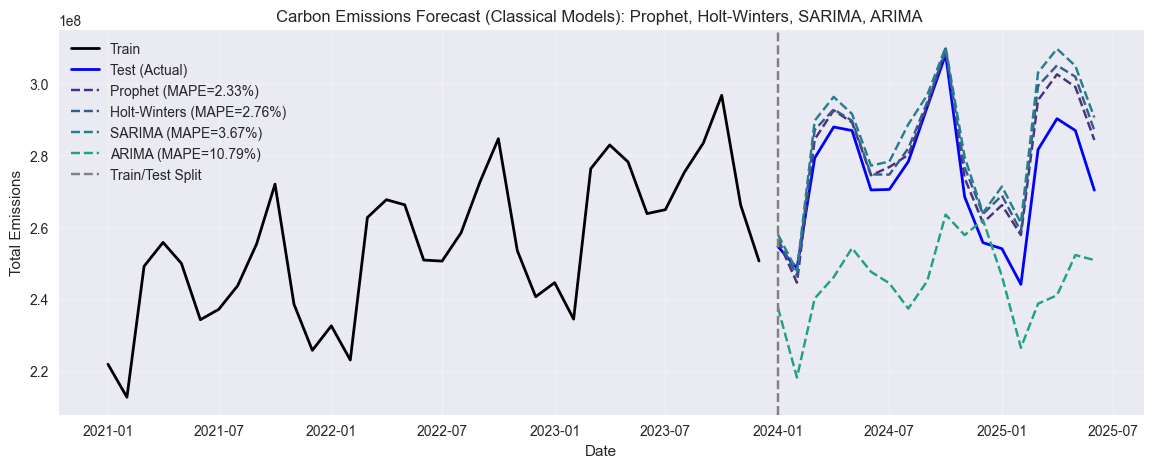

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error
from prophet import Prophet
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.style.use("seaborn-v0_8")  # updated style name
sns.set_palette("viridis")

# =========================================================
# 1) Train/Test split (Train: 2021-01 → 2023-12, Test: 2024-01 → 2025-05)
# =========================================================
df_monthly = df_final.groupby('start_time')['emissions_quantity'].sum().reset_index()
df_monthly = df_monthly.rename(columns={'start_time':'ds','emissions_quantity':'y'})
train = df_monthly[(df_monthly['ds'] >= '2021-01-01') & (df_monthly['ds'] < '2024-01-01')]
test  = df_monthly[(df_monthly['ds'] >= '2024-01-01') ]

y_train = train.set_index('ds')['y']
y_test  = test.set_index('ds')['y']

print(f"Train size: {len(train)} | range: {train['ds'].min().date()} → {train['ds'].max().date()}")
print(f"Test  size: {len(test)} | range: {test['ds'].min().date()} → {test['ds'].max().date()}")
# =========================================================
# 1.2) Fit Prophet on training data
# =========================================================
m = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m.fit(train)
# =========================================================
# 1.3) Create futures
# =========================================================
# (periods = number of months from end of train to 2025-05 inclusive)
last_needed = pd.Timestamp('2025-05-01')
months_needed = (last_needed.to_period('M') - train['ds'].max().to_period('M')).n + 1
future_full = m.make_future_dataframe(periods=months_needed, freq='MS')
forecast_full = m.predict(future_full)
future_test = pd.DataFrame({'ds': test['ds']})
forecast_test_only = m.predict(future_test)[['ds', 'yhat']]
missing_in_forecast = sorted(set(test['ds']) - set(forecast_test_only['ds']))
if missing_in_forecast:
    print("Warning: these test dates are missing predictions:", missing_in_forecast)

eval_df = test.merge(forecast_test_only, on='ds', how='left').copy()
if eval_df['yhat'].isna().any() or eval_df['y'].isna().any():
    n_nan_pred = eval_df['yhat'].isna().sum()
    n_nan_true = eval_df['y'].isna().sum()
    raise ValueError(f"Found NaNs after alignment -> yhat NaNs: {n_nan_pred}, y NaNs: {n_nan_true}. "
                    "Check the monthly continuity or date alignment.")
y_true = eval_df['y'].to_numpy()
y_pred = eval_df['yhat'].to_numpy()
mae  = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
# Robust MAPE: ignore zero-true months in the percentage calc
nonzero_mask = y_true != 0
if nonzero_mask.sum() == 0:
    mape = np.nan
else:
    mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
# sMAPE handles zeros better
smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
print("\nEvaluation (Test: 2024-01 → 2025-05)")
prophet_mape = mape
# -------------------------
# (2) Holt-Winters (monthly seasonality)
# -------------------------
hw_model = ExponentialSmoothing(y_train,
                                trend='add',
                                seasonal='add',
                                seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(len(y_test))

# -------------------------
# (3) ARIMA
# -------------------------
arima_model = ARIMA(y_train, order=(12,1,12))  
arima_fit = arima_model.fit()
arima_forecast = arima_fit.forecast(len(y_test))

# Seasonal ARIMA
import pmdarima as pm

sarima_model = pm.auto_arima(y_train,
                             seasonal=True,
                             m=12,  # 12 months in a seasonal cycle
                             stepwise=True,
                             suppress_warnings=True)
sarima_forecast = sarima_model.predict(n_periods=len(y_test))

sarima_mape = mean_absolute_percentage_error(y_test, sarima_forecast) * 100
# -------------------------
# Evaluate MAPE
# -------------------------
hw_mape = mean_absolute_percentage_error(y_test, hw_forecast) * 100
arima_mape = mean_absolute_percentage_error(y_test, arima_forecast) * 100
prophetPredictions=eval_df

print(f"Prophet MAPE: {prophet_mape:.2f}%")
print(f"Holt-Winters MAPE: {hw_mape:.2f}%")
print(f"ARIMA MAPE: {arima_mape:.2f}%")
print(f"SARIMA MAPE: {sarima_mape:.2f}%")



# -------------------------
# Plot Comparison
# -------------------------


plt.figure(figsize=(14,5))
plt.plot(train['ds'], train['y'], label="Train", color = 'black', linewidth=2)
plt.plot(test['ds'], test['y'], label="Test (Actual)", color='blue',linewidth=2)

# Prophet forecast (assuming you have eval_df with 'ds','yhat')
plt.plot(eval_df['ds'], eval_df['yhat'], '--', label=f"Prophet (MAPE={prophet_mape:.2f}%)")

# Holt-Winters forecast
plt.plot(test['ds'], hw_forecast, '--', label=f"Holt-Winters (MAPE={hw_mape:.2f}%)")

# ARIMA forecast
plt.plot(test['ds'], sarima_forecast, '--', label=f"SARIMA (MAPE={sarima_mape:.2f}%)")
plt.plot(test['ds'], arima_forecast, '--', label=f"ARIMA (MAPE={arima_mape:.2f}%)")


plt.axvline(pd.Timestamp('2024-01-01'), color='gray', linestyle='--', label="Train/Test Split")
plt.title("Carbon Emissions Forecast (Classical Models): Prophet, Holt-Winters, SARIMA, ARIMA ")
plt.xlabel("Date"); plt.ylabel("Total Emissions")
plt.legend(); plt.grid(alpha=0.3)
plt.show()


# ML Methods RandomForest, GradientBoosting, XGBoost, SVR

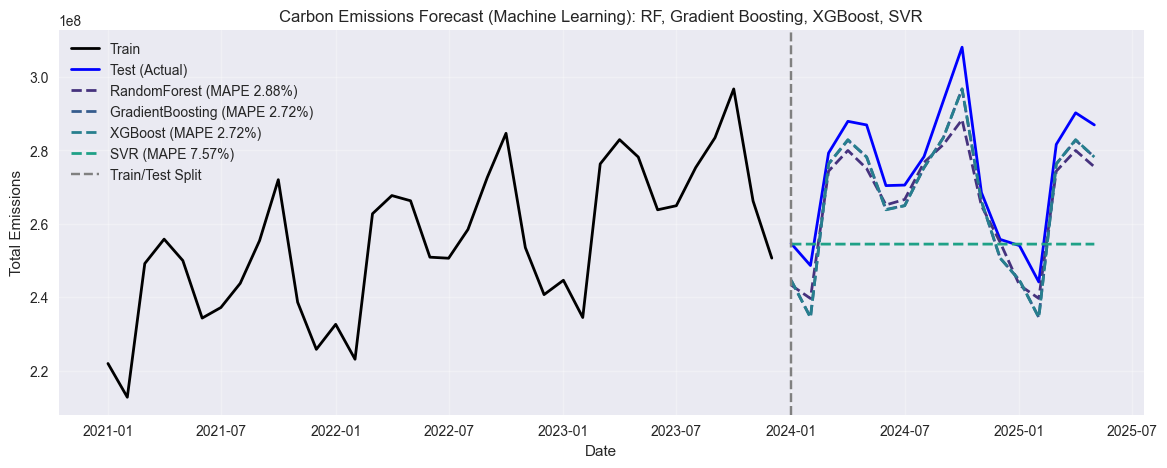


Model Comparison:
RandomForest: 2.88%
GradientBoosting: 2.72%
XGBoost: 2.72%
SVR: 7.57%


In [42]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

# ---------------------------
# Feature Engineering
# ---------------------------
def create_features(df_final):
    df_monthly = df_final.groupby('start_time')['emissions_quantity'].sum().reset_index()
    df_monthly = df_monthly.rename(columns={'start_time':'ds','emissions_quantity':'y'})
    df = df_monthly.copy()
    df['year'] = df['ds'].dt.year
    df['month'] = df['ds'].dt.month
    df['quarter'] = df['ds'].dt.quarter
    df['dayofyear'] = df['ds'].dt.dayofyear
    df['sin_month'] = np.sin(2 * np.pi * df['month']/12)
    df['cos_month'] = np.cos(2 * np.pi * df['month']/12)
    return df

df_ml = create_features(df_final)

# Train/Test split (same as earlier)
train_ml = df_ml[(df_ml['ds'] >= '2021-01-01') & (df_ml['ds'] < '2024-01-01')]
test_ml  = df_ml[(df_ml['ds'] >= '2024-01-01') & (df_ml['ds'] <= '2025-05-01')]

X_train = train_ml.drop(columns=['ds','y'])
y_train = train_ml['y']
X_test  = test_ml.drop(columns=['ds','y'])
y_test  = test_ml['y']

# ---------------------------
# Machine Learning Models
# ---------------------------

models = {
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=200, random_state=42),
    "SVR": SVR(kernel='rbf', C=200, gamma=0.1)
}

results = {}

import matplotlib.pyplot as plt

# ---------------------------
# Train ML models and store predictions
# ---------------------------
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    results[name] = mape


# ---------------------------
# Plot Train, Test, and Predictions
# ---------------------------
plt.figure(figsize=(14,5))

# Training data
plt.plot(train_ml['ds'], y_train, label="Train", color="black", linewidth=2)

# Test actual
plt.plot(test_ml['ds'], y_test, label="Test (Actual)", color="blue", linewidth=2)

# Forecasts from ML models
for name, y_pred in predictions.items():
    plt.plot(test_ml['ds'], y_pred, '--', label=f"{name} (MAPE {results[name]:.2f}%)", linewidth=2)

# Vertical line for train/test split
plt.axvline(pd.Timestamp("2024-01-01"), color="gray", linestyle="--", label="Train/Test Split")

plt.title("Carbon Emissions Forecast (Machine Learning): RF, Gradient Boosting, XGBoost, SVR")
plt.xlabel("Date")
plt.ylabel("Total Emissions")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---------------------------
# Compare All Models
# ---------------------------
print("\nModel Comparison:")
for model, mape in results.items():
    print(f"{model}: {mape:.2f}%")


# Hybrid Testing 

In [43]:
df=df_final.copy()

In [44]:
# =========================================================
# 0) Imports
# =========================================================
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from prophet import Prophet

# =========================================================
# 1) Prepare India data
# =========================================================
df_india=df.copy()

# Aggregate monthly totals
df_monthly = df_india.groupby('start_time').agg({
    'emissions_quantity':'sum',
    'activity':'sum',
    'capacity':'sum',
    'capacity_factor':'mean'
}).reset_index()

# rename for clarity
df_monthly = df_monthly.rename(columns={
    'start_time':'ds',
    'emissions_quantity':'y',
    'activity':'activity',
    'capacity':'capacity',
    'capacity_factor':'capacity_factor'
})

#Measurements of error
def robust_mape(y_true, y_pred):
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) *100

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

def compute_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = robust_mape(y_true, y_pred)
    smape_val = smape(y_true, y_pred)
    return pd.DataFrame({
        'Model': [name],
        'MAPE (%)': [mape_val],
        'MAE': [mae],
        'RMSE': [rmse],
        'sMAPE (%)': [smape_val]
    })

# =========================================================
# 2) Train/Test split by date
# =========================================================
train = df_monthly[(df_monthly['ds'] >= '2021-01-01') & (df_monthly['ds'] < '2024-01-01')].copy()
test  = df_monthly[(df_monthly['ds'] >= '2024-01-01') ].copy()

X_train = train[['activity','capacity','capacity_factor']].values
y_train = train['y'].values
X_test  = test[['activity','capacity','capacity_factor']].values
y_test  = test['y'].values

# =========================================================
# 3) Scale features and target
# =========================================================
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

# =========================================================
# 4) Define PINN with MAPE-compatible loss
# =========================================================
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# =========================================================
# PINN Definition
# =========================================================
class PINN(nn.Module):
    def __init__(self, input_dim=3, hidden=64):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        return self.net(x)

# Differentiable MAPE loss
class MAPELoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps
    def forward(self, y_pred, y_true):
        return torch.mean(torch.abs(y_pred - y_true) / (torch.abs(y_true) + self.eps))

# Physics-informed residual loss
def physics_residual_loss(y_pred, features, eps=1e-6):
    # features assumed to have: [activity, emission_factor, capacity_factor, ...]
    activity = features[:, 0]
    ef = features[:, 1]
    cf = features[:, 2]
    physics_estimate = activity * ef * cf
    return torch.mean((y_pred.squeeze() - physics_estimate) ** 2)

# =========================================================
# 5) Prepare PyTorch DataLoader
# =========================================================
X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1,1)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Instantiate model, optimizer, loss
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = MAPELoss()

# =========================================================
# 6) Train NN
# =========================================================
counterEpoch=1
while counterEpoch!=0:
    def train_pinn(model, loader, optimizer, loss_fn, epochs=5000, lambda_phys=0):
        model.train()
        for epoch in range(epochs):
            for xb, yb in loader:
                optimizer.zero_grad()
                y_pred = model(xb)
                # Data loss
                loss_data = loss_fn(y_pred, yb)
                # Physics loss (using first 3 cols as activity, ef, cf)
                loss_phys = physics_residual_loss(y_pred, xb[:, :3])
                # Total loss
                loss = loss_data + lambda_phys * loss_phys
                loss.backward()
                optimizer.step()
            # if epoch % 500 == 0:
            #     print(f"Epoch {epoch}, MAPE Loss: {loss.item():.6f}")


    lambda_phys = 1  # weight for physics-informed loss
    train_pinn(model, loader, optimizer, loss_fn, epochs=5000, lambda_phys=lambda_phys)


    # =========================================================
    # 7) PINN predictions (scaled -> original)
    # =========================================================
    model.eval()
    with torch.no_grad():
        y_pinn_train_scaled = model(torch.tensor(X_train_scaled, dtype=torch.float32)).numpy().flatten()
        y_pinn_test_scaled  = model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().flatten()

    y_pinn_train = scaler_y.inverse_transform(y_pinn_train_scaled.reshape(-1,1)).flatten()
    y_pinn_test  = scaler_y.inverse_transform(y_pinn_test_scaled.reshape(-1,1)).flatten()

    train['pinn_pred'] = y_pinn_train
    train['residual'] = train['y'] - train['pinn_pred']
    test['pinn_pred']  = y_pinn_test
    test['residual']   = test['y'] - test['pinn_pred']
    model = PINN()

    train_pinn(model, loader, optimizer, loss_fn, epochs=5000, lambda_phys=lambda_phys)
    model.eval()
    with torch.no_grad():
        y_pinn_test_scaled  = model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().flatten()
    y_pinn_test  = scaler_y.inverse_transform(y_pinn_test_scaled.reshape(-1,1)).flatten()


    # =========================================================
    # 8B) Residual modeling with Prophet
    # =========================================================
    train_res = train[['ds','residual']].rename(columns={'residual':'y'})
    test_res  = test[['ds','residual']].rename(columns={'residual':'y'})

    m_res = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    m_res.fit(train_res)

    future_res = m_res.make_future_dataframe(periods=len(test_res), freq='MS')
    forecast_res = m_res.predict(future_res)
    res_pred_prophet = forecast_res['yhat'].iloc[len(train_res):].values
    final_pred_prophet = test['pinn_pred'].values + res_pred_prophet
    y_true_test = test['y'].values
    hybrid_mape=robust_mape(y_true_test, final_pred_prophet)
  
    counterEpoch-=1
# =========================================================
# 8A) Residual modeling with XGBoost
# =========================================================
# Simple lag features
train['res_lag1'] = train['residual'].shift(1).fillna(0)
train['res_lag2'] = train['residual'].shift(2).fillna(0)
test['res_lag1']  = list(train['residual'].iloc[-2:]) + list(test['residual'].iloc[:-2])
test['res_lag2']  = list(train['residual'].iloc[-1:]) + list(test['residual'].iloc[:-1])

X_res_train = train[['res_lag1','res_lag2','activity','capacity','capacity_factor']]
y_res_train = train['residual']
X_res_test  = test[['res_lag1','res_lag2','activity','capacity','capacity_factor']]

dtrain = xgb.DMatrix(X_res_train, y_res_train)
dtest  = xgb.DMatrix(X_res_test)
params = {'objective':'reg:squarederror','verbosity':0}
bst = xgb.train(params, dtrain, num_boost_round=300)

res_pred_xgb = bst.predict(dtest)
final_pred_xgb = test['pinn_pred'].values + res_pred_xgb

# =========================================================
# 9) Evaluation metrics
# =========================================================

y_true_test = test['y'].values
df_metrics = pd.concat([
    compute_metrics(y_true_test, y_pinn_test, 'NN-only'),
    compute_metrics(y_true_test, final_pred_xgb, 'NN + XGBoost'),
    compute_metrics(y_true_test, final_pred_prophet, 'NN + Prophet')
], ignore_index=True)
NN_mape=robust_mape(y_true_test, y_pinn_test)        
print(df_metrics[['Model','MAPE (%)']])


14:20:54 - cmdstanpy - INFO - Chain [1] start processing
14:20:54 - cmdstanpy - INFO - Chain [1] done processing


          Model  MAPE (%)
0       NN-only      7.94
1  NN + XGBoost      4.39
2  NN + Prophet      1.59


In [45]:
def alphatest(df,alpha):
    # =========================================================
    # 0) Imports
    # =========================================================
    import pandas as pd
    import numpy as np
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    from sklearn.preprocessing import StandardScaler
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    import xgboost as xgb
    from prophet import Prophet

    # =========================================================
    # 1) Prepare India data
    # =========================================================
    df_india=df.copy()

    # Aggregate monthly totals
    df_monthly = df_india.groupby('start_time').agg({
        'emissions_quantity':'sum',
        'activity':'sum',
        'capacity':'sum',
        'capacity_factor':'mean'
    }).reset_index()

    # rename for clarity
    df_monthly = df_monthly.rename(columns={
        'start_time':'ds',
        'emissions_quantity':'y',
        'activity':'activity',
        'capacity':'capacity',
        'capacity_factor':'capacity_factor'
    })

    #Measurements of error
    def robust_mape(y_true, y_pred):
        mask = y_true != 0
        if mask.sum() == 0:
            return np.nan
        return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) *100

    def smape(y_true, y_pred):
        return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))

    def compute_metrics(y_true, y_pred, name):
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mape_val = robust_mape(y_true, y_pred)
        smape_val = smape(y_true, y_pred)
        return pd.DataFrame({
            'Model': [name],
            'MAPE (%)': [mape_val],
            'MAE': [mae],
            'RMSE': [rmse],
            'sMAPE (%)': [smape_val]
        })

    # =========================================================
    # 2) Train/Test split by date
    # =========================================================
    train = df_monthly[(df_monthly['ds'] >= '2021-01-01') & (df_monthly['ds'] < '2024-01-01')].copy()
    test  = df_monthly[(df_monthly['ds'] >= '2024-01-01') ].copy()

    X_train = train[['activity','capacity','capacity_factor']].values
    y_train = train['y'].values
    X_test  = test[['activity','capacity','capacity_factor']].values
    y_test  = test['y'].values

    # =========================================================
    # 3) Scale features and target
    # =========================================================
    scaler_X = StandardScaler()
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    scaler_y = StandardScaler()
    y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1)).flatten()
    y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1)).flatten()

    # =========================================================
    # 4) Define PINN with MAPE-compatible loss
    # =========================================================
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader

    # =========================================================
    # PINN Definition
    # =========================================================
    class PINN(nn.Module):
        def __init__(self, input_dim=3, hidden=64):
            super(PINN, self).__init__()
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden),
                nn.Tanh(),
                nn.Linear(hidden, hidden),
                nn.Tanh(),
                nn.Linear(hidden, 1)
            )
        def forward(self, x):
            return self.net(x)

    # Differentiable MAPE loss
    class MAPELoss(nn.Module):
        def __init__(self, eps=1e-6):
            super().__init__()
            self.eps = eps
        def forward(self, y_pred, y_true):
            return torch.mean(torch.abs(y_pred - y_true) / (torch.abs(y_true) + self.eps))

    # Physics-informed residual loss
    def physics_residual_loss(y_pred, features, eps=1e-6):
        # features assumed to have: [activity, emission_factor, capacity_factor, ...]
        activity = features[:, 0]
        ef = features[:, 1]
        cf = features[:, 2]
        physics_estimate = activity * ef * cf
        return torch.mean((y_pred.squeeze() - physics_estimate) ** 2)

    # =========================================================
    # 5) Prepare PyTorch DataLoader
    # =========================================================
    X_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
    y_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1,1)

    dataset = TensorDataset(X_tensor, y_tensor)
    loader = DataLoader(dataset, batch_size=32, shuffle=True)

    # Instantiate model, optimizer, loss
    model = PINN()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    loss_fn = MAPELoss()

    # =========================================================
    # 6) Train PINN
    # =========================================================
    counterEpoch=1
    while counterEpoch!=0:
        def train_pinn(model, loader, optimizer, loss_fn, epochs=5000, lambda_phys=0):
            model.train()
            for epoch in range(epochs):
                for xb, yb in loader:
                    optimizer.zero_grad()
                    y_pred = model(xb)
                    # Data loss
                    loss_data = loss_fn(y_pred, yb)
                    # Physics loss (using first 3 cols as activity, ef, cf)
                    loss_phys = physics_residual_loss(y_pred, xb[:, :3])
                    # Total loss
                    loss = loss_data + lambda_phys * loss_phys
                    loss.backward()
                    optimizer.step()
                # if epoch % 500 == 0:
                #     print(f"Epoch {epoch}, MAPE Loss: {loss.item():.6f}")


        lambda_phys = alpha # weight for physics-informed loss
        train_pinn(model, loader, optimizer, loss_fn, epochs=5000, lambda_phys=lambda_phys)


        # =========================================================
        # 7) PINN predictions (scaled -> original)
        # =========================================================
        model.eval()
        with torch.no_grad():
            y_pinn_train_scaled = model(torch.tensor(X_train_scaled, dtype=torch.float32)).numpy().flatten()
            y_pinn_test_scaled  = model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().flatten()

        y_pinn_train = scaler_y.inverse_transform(y_pinn_train_scaled.reshape(-1,1)).flatten()
        y_pinn_test  = scaler_y.inverse_transform(y_pinn_test_scaled.reshape(-1,1)).flatten()

        train['pinn_pred'] = y_pinn_train
        train['residual'] = train['y'] - train['pinn_pred']
        test['pinn_pred']  = y_pinn_test
        test['residual']   = test['y'] - test['pinn_pred']
        model = PINN()

        train_pinn(model, loader, optimizer, loss_fn, epochs=5000, lambda_phys=lambda_phys)
        model.eval()
        with torch.no_grad():
            y_pinn_test_scaled  = model(torch.tensor(X_test_scaled, dtype=torch.float32)).numpy().flatten()
        y_pinn_test  = scaler_y.inverse_transform(y_pinn_test_scaled.reshape(-1,1)).flatten()


        # =========================================================
        # 8B) Residual modeling with Prophet
        # =========================================================
        train_res = train[['ds','residual']].rename(columns={'residual':'y'})
        test_res  = test[['ds','residual']].rename(columns={'residual':'y'})

        m_res = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        m_res.fit(train_res)

        future_res = m_res.make_future_dataframe(periods=len(test_res), freq='MS')
        forecast_res = m_res.predict(future_res)
        res_pred_prophet = forecast_res['yhat'].iloc[len(train_res):].values
        final_pred_prophet = test['pinn_pred'].values + res_pred_prophet
        y_true_test = test['y'].values
        hybrid_mape=robust_mape(y_true_test, final_pred_prophet)
        counterEpoch-=1
    # =========================================================
    # 8A) Residual modeling with XGBoost
    # =========================================================
    # Simple lag features
    train['res_lag1'] = train['residual'].shift(1).fillna(0)
    train['res_lag2'] = train['residual'].shift(2).fillna(0)
    test['res_lag1']  = list(train['residual'].iloc[-2:]) + list(test['residual'].iloc[:-2])
    test['res_lag2']  = list(train['residual'].iloc[-1:]) + list(test['residual'].iloc[:-1])

    X_res_train = train[['res_lag1','res_lag2','activity','capacity','capacity_factor']]
    y_res_train = train['residual']
    X_res_test  = test[['res_lag1','res_lag2','activity','capacity','capacity_factor']]

    dtrain = xgb.DMatrix(X_res_train, y_res_train)
    dtest  = xgb.DMatrix(X_res_test)
    params = {'objective':'reg:squarederror','verbosity':0}
    bst = xgb.train(params, dtrain, num_boost_round=300)

    res_pred_xgb = bst.predict(dtest)
    final_pred_xgb = test['pinn_pred'].values + res_pred_xgb

    # =========================================================
    # 9) Evaluation metrics
    # =========================================================

    y_true_test = test['y'].values
    df_metrics = pd.concat([
        compute_metrics(y_true_test, y_pinn_test, 'NN-only'),
        compute_metrics(y_true_test, final_pred_xgb, 'NN + XGBoost'),
        compute_metrics(y_true_test, final_pred_prophet, 'NN + Prophet')
    ], ignore_index=True)
    NN_mape=robust_mape(y_true_test, y_pinn_test)

    return df_metrics,y_pinn_test,prophetPredictions['yhat'],final_pred_prophet


In [46]:
metricsCollection=[]
for alpha in [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]:
    df_metrics,y_pinn_test,prophet_pred,final_pred_prophet=alphatest(df,alpha)
    metricsCollection.append((alpha, df_metrics))


14:21:02 - cmdstanpy - INFO - Chain [1] start processing
14:21:02 - cmdstanpy - INFO - Chain [1] done processing
14:21:10 - cmdstanpy - INFO - Chain [1] start processing
14:21:10 - cmdstanpy - INFO - Chain [1] done processing
14:21:18 - cmdstanpy - INFO - Chain [1] start processing
14:21:18 - cmdstanpy - INFO - Chain [1] done processing
14:21:26 - cmdstanpy - INFO - Chain [1] start processing
14:21:26 - cmdstanpy - INFO - Chain [1] done processing
14:21:34 - cmdstanpy - INFO - Chain [1] start processing
14:21:34 - cmdstanpy - INFO - Chain [1] done processing
14:21:42 - cmdstanpy - INFO - Chain [1] start processing
14:21:42 - cmdstanpy - INFO - Chain [1] done processing
14:21:50 - cmdstanpy - INFO - Chain [1] start processing
14:21:50 - cmdstanpy - INFO - Chain [1] done processing
14:21:59 - cmdstanpy - INFO - Chain [1] start processing
14:21:59 - cmdstanpy - INFO - Chain [1] done processing
14:22:07 - cmdstanpy - INFO - Chain [1] start processing
14:22:07 - cmdstanpy - INFO - Chain [1]

    Alpha  MAPE
0     0.0  2.33
1     0.1  2.09
2     0.2  1.75
3     0.3  1.92
4     0.4  1.96
5     0.5  1.60
6     0.6  1.77
7     0.7  1.95
8     0.8  1.98
9     0.9  1.77
10    1.0  1.59


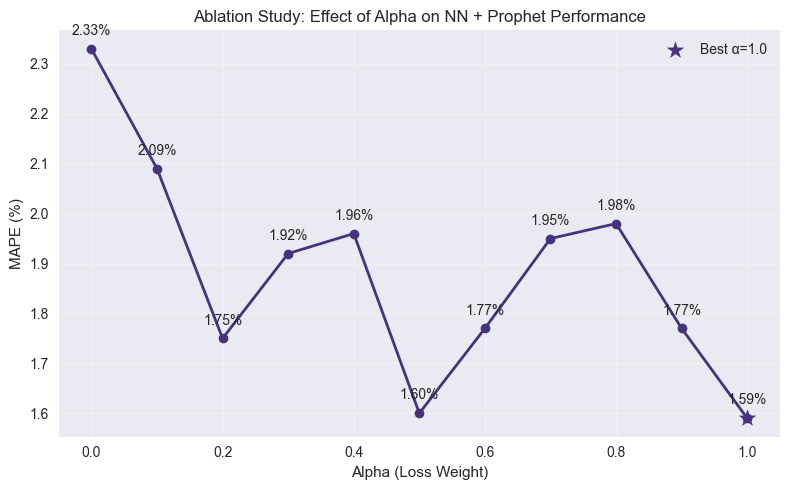

In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
plt.style.use("seaborn-v0_8")  # updated style name
sns.set_palette("viridis")

# Collect NN+Prophet results
ablation_results = []

for alpha, df_metrics in metricsCollection:
    prophet_row = df_metrics[df_metrics["Model"] == "NN + Prophet"].iloc[0]

    ablation_results.append({
        "Alpha": alpha,
        "MAPE": prophet_row["MAPE (%)"],
        "MAE": prophet_row["MAE"],
        "RMSE": prophet_row["RMSE"],
        "sMAPE": prophet_row["sMAPE (%)"]
    })

ablation_df = pd.DataFrame(ablation_results)
print(ablation_df[["Alpha", "MAPE"]])

# -----------------------------
# Ablation Plot
# -----------------------------
plt.figure(figsize=(8,5))

plt.plot(
    ablation_df["Alpha"],
    ablation_df["MAPE"],
    marker='o',
    linewidth=2
)

for x, y in zip(ablation_df["Alpha"], ablation_df["MAPE"]):
    plt.annotate(
        f"{y:.2f}%",
        (x, y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

best_idx = ablation_df["MAPE"].idxmin()

plt.scatter(
    ablation_df.loc[best_idx, "Alpha"],
    ablation_df.loc[best_idx, "MAPE"],
    s=150,
    marker='*',
    label=f'Best α={ablation_df.loc[best_idx, "Alpha"]}'
)

plt.xlabel("Alpha (Loss Weight)")
plt.ylabel("MAPE (%)")
plt.title("Ablation Study: Effect of Alpha on NN + Prophet Performance")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# Augmentation

ORIGINAL DATASET
Train: 37 samples
Test:  17 samples

PHASE 2: DECOMPOSITION-AWARE AUGMENTATION

[DECOMPOSITION] Seasonal period: 12
[DECOMPOSITION] Trend shape: (37,)
[DECOMPOSITION] Seasonal shape: (37,)
[DECOMPOSITION] Residual shape: (37,)


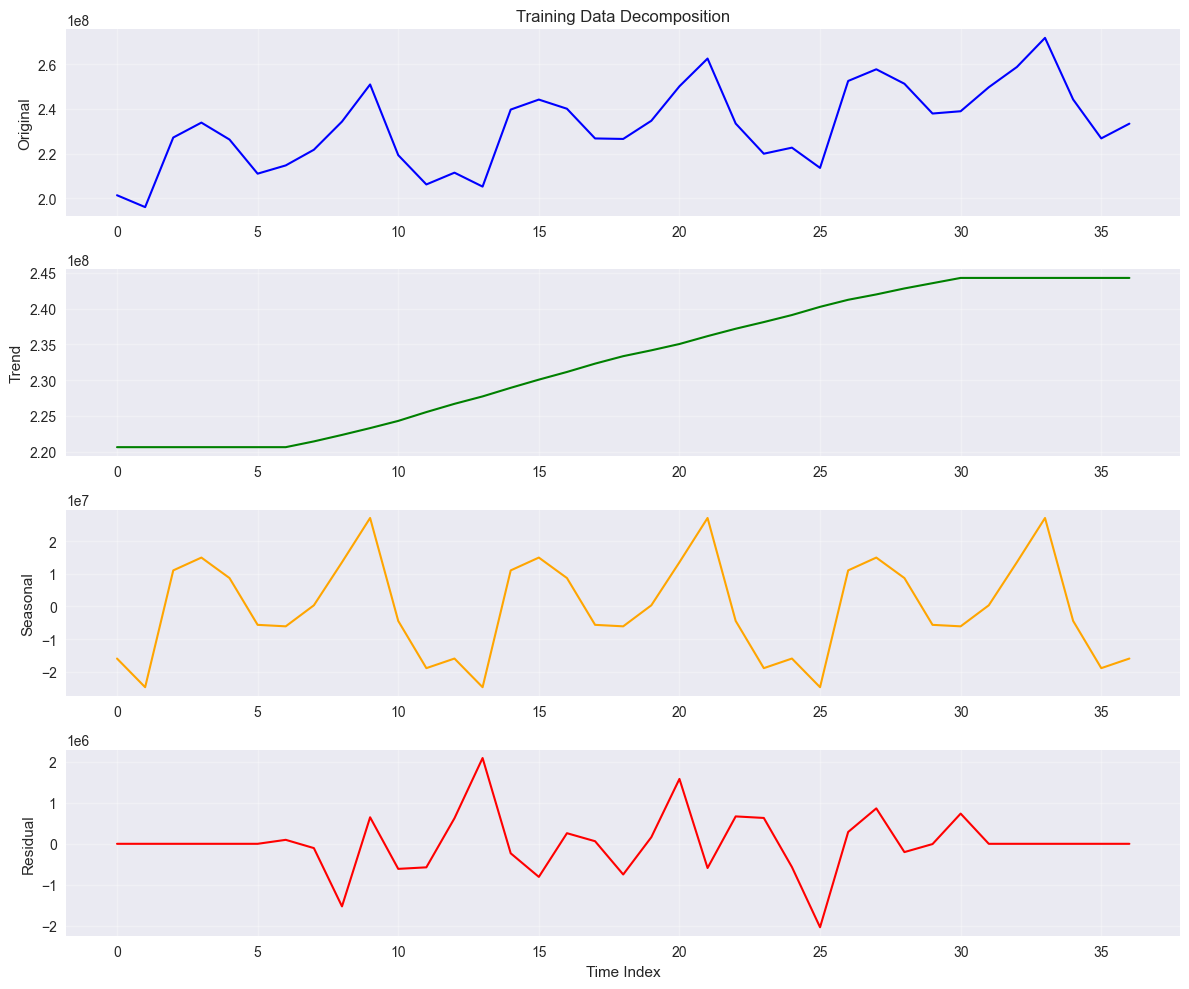


[AUGMENTATION] Created 4 augmented samples
[AUGMENTATION] Jitter std multiplier: 0.05


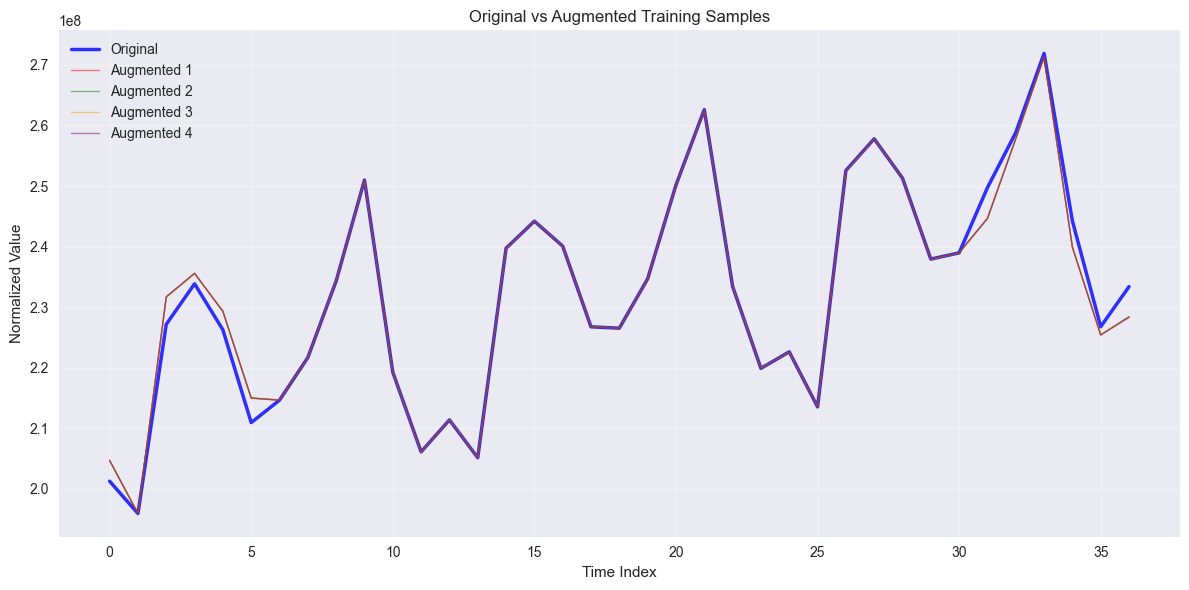

15:21:26 - cmdstanpy - INFO - Chain [1] start processing



[PROPHET TRAINING DATA]
Original: 37
Augmented: 185

TRAINING PROPHET WITH AUGMENTED DATA


15:21:26 - cmdstanpy - INFO - Chain [1] done processing
15:21:28 - cmdstanpy - INFO - Chain [1] start processing
15:21:29 - cmdstanpy - INFO - Chain [1] done processing



[Training Log] 140 epochs logged

METRICS SUMMARY TABLE (WITH AUGMENTATION)
                  Model   MAPE
          Prophet (Aug) 0.2772
          NN (Original) 6.7493
Hybrid (NN+Prophet Aug) 0.1301

AUGMENTATION PIPELINE COMPLETED


In [48]:
# PHASE 2: DECOMPOSITION-AWARE AUGMENTATION
# Modified code with data augmentation pipeline
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_percentage_error,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim

plt.style.use("seaborn-v0_8")

RANDOM_SEED   = 42
DATE_COL      = "start_time"
TARGET_COL    = "emissions_quantity"
PLANT_COL     = "sector"
TEST_MONTHS   = 17
PHYS_COL      = "activity"
TargetCol_raw = "y"
ProductionCol = "activity"

# ============================================================
# 0) NEW: AUGMENTATION PARAMETERS
# ============================================================
NUM_AUGMENTED_SAMPLES = 4  
JITTER_STD_MULTIPLIER = 0.05  # sigma = 0.05 * std(residuals)
DECOMPOSITION_PERIOD = 12  


# ============================================================
# 1) SEEDING
# ============================================================
def set_seed(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)


# ============================================================
# 2) DATA PREP FUNCTIONS (ORIGINAL)
# ============================================================
def ensure_datetime_column(df: pd.DataFrame,
                           date_col: str = DATE_COL) -> pd.DataFrame:
    """Ensure a monthly datetime column 'ds' exists."""
    if date_col in df.columns:
        ds = pd.to_datetime(df[date_col], errors="coerce", infer_datetime_format=True)
    else:
        print("Warning: date_col not found, attempting to use 'ds' column.")
        ds = pd.Series(pd.NaT, index=df.index)

    needs_rebuild = ds.isna()
    if needs_rebuild.any():
        if not {"year", "month"}.issubset(df.columns):
            raise ValueError(
                "No valid datetime and missing 'year'/'month' to rebuild dates."
            )
        ds_rebuilt = pd.to_datetime(
            dict(
                year=df.loc[needs_rebuild, "year"],
                month=df.loc[needs_rebuild, "month"],
                day=1,
            )
        )
        ds.loc[needs_rebuild] = ds_rebuilt

    df["ds"] = pd.to_datetime(ds).dt.to_period("M").dt.to_timestamp()
    return df


def clean_and_impute(df: pd.DataFrame) -> pd.DataFrame:
    """Drop duplicates and impute numeric columns (0→NaN→mean)."""
    if {"ds", PLANT_COL, TARGET_COL}.issubset(df.columns):
        df = df.drop_duplicates(subset=["ds", PLANT_COL, TARGET_COL], keep="last")

    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    def impute_zero_nan_with_mean(group: pd.DataFrame) -> pd.DataFrame:
        g = group.copy()
        for c in num_cols:
            g[c] = g[c].replace(0, np.nan)
            if g[c].notna().any():
                g[c] = g[c].fillna(g[c].mean())
        return g

    if "year" in df.columns:
        df = df.groupby("year", group_keys=False).apply(impute_zero_nan_with_mean)
    else:
        df = impute_zero_nan_with_mean(df)

    for c in num_cols:
        if df[c].isna().any():
            df[c] = df[c].fillna(df[c].mean())

    return df


def prepare_overall_series2(df: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregate ALL numeric columns across plants into a single monthly series.
    For each month (ds), returns the sum of every numeric column.
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    if "ds" not in df.columns:
        raise ValueError("The dataframe must contain a 'ds' datetime column.")

    agg = (
        df.groupby("ds", as_index=False)[numeric_cols]
          .sum()
          .sort_values("ds")
          .reset_index(drop=True)
    )

    return agg


def compute_metrics(y_true, y_pred, prefix=""):
    """
    Compute common regression metrics.
    Assumes inputs are 1D numpy arrays.
    """
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)*10
    r2   = r2_score(y_true, y_pred)

    return {
        f"{prefix}MAE": mae,
        f"{prefix}RMSE": rmse,
        f"{prefix}MAPE": mape,
        f"{prefix}R2": r2,
    }


# ============================================================
# NEW SECTION: DECOMPOSITION-AWARE AUGMENTATION FUNCTIONS
# ============================================================
def decompose_time_series(series: pd.Series, 
                          period: int = DECOMPOSITION_PERIOD) -> dict:
    
    # Ensure we have enough data for decomposition
    if len(series) < 2 * period:
        print(f"Warning: Series length ({len(series)}) < 2*period ({2*period}). "
              f"Adjusting period to {len(series)//2}.")
        period = max(2, len(series) // 2)
    
    try:
        decomposition = seasonal_decompose(
            series, 
            model='additive', 
            period=period,
            
        )
        
        return {
            'trend': decomposition.trend.fillna(method="bfill").fillna(method="ffill").values,
            'seasonal': decomposition.seasonal.values,
            'residual': decomposition.resid.fillna(0).values,
            'period': period
        }
    except Exception as e:
        print(f"Decomposition failed: {e}. Returning zero components.")
        return {
            'trend': series.values,
            'seasonal': np.zeros_like(series.values),
            'residual': np.zeros_like(series.values),
            'period': period
        }


def apply_jittering(residuals: np.ndarray, 
                   std_multiplier: float = JITTER_STD_MULTIPLIER) -> np.ndarray:

    residual_std = np.std(residuals[~np.isnan(residuals)])
    if residual_std == 0:
        residual_std = 1.0
    
    noise_std = std_multiplier * residual_std
    jitter = np.random.normal(0, noise_std, size=len(residuals))
    
    return residuals + jitter


def create_augmented_samples(series: pd.Series,
                             num_samples: int = NUM_AUGMENTED_SAMPLES,
                             decomposition_dict: dict = None) -> list:
    """
    Create augmented time series by:
    1. Decomposing into trend, seasonal, residual
    2. Jittering the residual component
    3. Reconstructing: T + S + (R + jitter)
    """
    if decomposition_dict is None:
        decomposition_dict = decompose_time_series(series)
    
    trend = decomposition_dict['trend']
    seasonal = decomposition_dict['seasonal']
    residual = decomposition_dict['residual']
    
    augmented_samples = []
    
    for i in range(num_samples):
        # Apply jittering to residuals
        jittered_residual = apply_jittering(residual.copy())
        
        # Reconstruct: T + S + (R + jitter)
        augmented_series = trend + seasonal + jittered_residual
        augmented_samples.append(augmented_series)
    
    return augmented_samples


def prepare_augmented_training_data(train_df: pd.DataFrame,
                                   num_augmented: int = NUM_AUGMENTED_SAMPLES,
                                   decomposition_dict: dict = None) -> pd.DataFrame:
    
    original_series = pd.Series(train_df['y_norm'].values, index=range(len(train_df)))
    
    # Create augmented samples
    augmented_samples = create_augmented_samples(
        original_series,
        num_samples=num_augmented,
        decomposition_dict=decomposition_dict
    )
    
    # Prepare augmented dataframes
    augmented_dfs = []
    
    # Add original data
    augmented_dfs.append(train_df.copy())
    
    # Add augmented data
    for idx, aug_values in enumerate(augmented_samples):
        aug_df = train_df[['ds', 'y']].copy() if 'y' in train_df.columns else train_df[['ds']].copy()
        aug_df['y_norm'] = aug_values
        if 'y' not in aug_df.columns:
            aug_df['y'] = aug_values  # For Prophet
        else:
            aug_df['y'] = aug_values  # Overwrite with augmented values
        
        # Optional: Add metadata for tracking
        aug_df['augmented'] = True
        aug_df['augmentation_id'] = idx
        augmented_dfs.append(aug_df)
    
    # Concatenate all
    augmented_train = pd.concat(augmented_dfs, ignore_index=True)
    
    print(f"\n[AUGMENTATION] Original training size: {len(train_df)}")
    print(f"[AUGMENTATION] Augmented versions created: {num_augmented}")
    print(f"[AUGMENTATION] Total augmented training size: {len(augmented_train)}")
    
    return augmented_train


def visualize_decomposition(series: pd.Series, 
                           decomposition_dict: dict,
                           title: str = "Time Series Decomposition") -> None:
    """
    Visualize the decomposition of a time series.
    """
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    
    # Original series
    axes[0].plot(series.index, series.values, 'b-', linewidth=1.5)
    axes[0].set_ylabel('Original')
    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    
    # Trend
    axes[1].plot(series.index, decomposition_dict['trend'], 'g-', linewidth=1.5)
    axes[1].set_ylabel('Trend')
    axes[1].grid(True, alpha=0.3)
    
    # Seasonal
    axes[2].plot(series.index, decomposition_dict['seasonal'], 'orange', linewidth=1.5)
    axes[2].set_ylabel('Seasonal')
    axes[2].grid(True, alpha=0.3)
    
    # Residual
    axes[3].plot(series.index, decomposition_dict['residual'], 'r-', linewidth=1.5)
    axes[3].set_ylabel('Residual')
    axes[3].set_xlabel('Time Index')
    axes[3].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def visualize_augmented_samples(original_series: pd.Series,
                               augmented_samples: list,
                               title: str = "Original vs Augmented Series") -> None:
    """
    Visualize original series and augmented versions.
    """
    plt.figure(figsize=(12, 6))
    
    # Plot original
    plt.plot(original_series.index, original_series.values, 
             'b-', linewidth=2.5, label='Original', alpha=0.8)
    
    # Plot augmented samples
    colors = ['red', 'green', 'orange', 'purple', 'brown']
    for idx, aug in enumerate(augmented_samples):
        plt.plot(original_series.index, aug, 
                linewidth=1, alpha=0.5, 
                label=f'Augmented {idx+1}',
                color=colors[idx % len(colors)])
    
    plt.xlabel('Time Index')
    plt.ylabel('Normalized Value')
    plt.title(title)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ============================================================
# 3) NN MODEL DEFINITION (ORIGINAL - PINN class assumed)
# ============================================================
class NN(nn.Module):
    def __init__(self, in_dim=1, hidden_dim=32, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )

    def forward(self, x):
        return self.net(x)


def regression_from_numpy_normalized(x, y):
    """
    Normalize x and y, then compute linear regression y = m*x + c.
    Returns m, c and plots the regression line on normalized data.
    """
    x = x.flatten().reshape(-1, 1)
    y = y.flatten().reshape(-1, 1)

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()

    x_norm = scaler_x.fit_transform(x).flatten()
    y_norm = scaler_y.fit_transform(y).flatten()

    x_mean = x_norm.mean()
    y_mean = y_norm.mean()

    m = np.sum((x_norm - x_mean) * (y_norm - y_mean)) / np.sum((x_norm - x_mean) ** 2)
    c = y_mean - m * x_mean

    plt.figure(figsize=(8, 5))
    plt.scatter(x_norm, y_norm, alpha=0.7, label="Normalized Data")

    x_line = np.linspace(x_norm.min(), x_norm.max(), 100)
    y_line = m * x_line + c

    plt.plot(x_line, y_line, color="red", linewidth=2,
             label=f"y = {m:.4f}x + {c:.4f}")

    plt.xlabel("x (normalized)")
    plt.ylabel("y (normalized)")
    plt.title("Linear Regression on Normalized Data")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return m, c


def physics_residual_loss(y_pred: torch.Tensor,
                          features: torch.Tensor,
                          eps: float = 1e-6) -> torch.Tensor:
    delta = 0.75
    elec = features[:, 0]
    c02  = features[:, 1]
    prod = features[:, 2]

    # Rule-based reference (not physics)
    rule = (0.4727 * elec) / prod

    # Normalised deviation from the rule
    diff = (y_pred.squeeze() - rule) / (torch.abs(rule) + eps)
    
    # Huber-style soft rule penalty
    penalty = torch.where(
        torch.abs(diff) <= delta,
        0.5 * diff**2,
        delta * (torch.abs(diff) - 0.5 * delta)
    )

    return penalty.mean()


# ============================================================
# MAIN PIPELINE WITH AUGMENTATION
# ============================================================

# [ORIGINAL PIPELINE UP TO TRAIN/TEST SPLIT]
df_raw = df_final.copy()

df = ensure_datetime_column(df_raw, date_col=DATE_COL)
df = clean_and_impute(df)

overall = prepare_overall_series2(df)
overall = overall.sort_values("ds").reset_index(drop=True)
overall = overall.rename(columns={TARGET_COL: "y"})

# --- GLOBAL SCALING (Prophet + Hybrid + Final Outputs) ---
scaler_y_global = StandardScaler()
overall["y_norm"] = scaler_y_global.fit_transform(overall[["y"]])

# Train/test split
split_point = len(overall) - TEST_MONTHS
train_overall = overall.iloc[:split_point].copy()
test_overall  = overall.iloc[split_point:].copy()

print("=" * 60)
print("ORIGINAL DATASET")
print("=" * 60)
print(f"Train: {len(train_overall)} samples")
print(f"Test:  {len(test_overall)} samples")


# ============================================================
# PHASE 2: DECOMPOSITION-AWARE AUGMENTATION
# ============================================================
print("\n" + "=" * 60)
print("PHASE 2: DECOMPOSITION-AWARE AUGMENTATION")
print("=" * 60)

# Step 1: Decompose the original training series
original_train_series = pd.Series(
    train_overall['y'].values,
    index=range(len(train_overall))
)

decomposition_dict = decompose_time_series(
    original_train_series,
    period=DECOMPOSITION_PERIOD
)

print(f"\n[DECOMPOSITION] Seasonal period: {decomposition_dict['period']}")
print(f"[DECOMPOSITION] Trend shape: {decomposition_dict['trend'].shape}")
print(f"[DECOMPOSITION] Seasonal shape: {decomposition_dict['seasonal'].shape}")
print(f"[DECOMPOSITION] Residual shape: {decomposition_dict['residual'].shape}")

# Visualize decomposition (optional - comment out if not needed)
visualize_decomposition(original_train_series, decomposition_dict, 
                       title="Training Data Decomposition")

# Step 2: Create augmented samples
augmented_samples = create_augmented_samples(
    original_train_series,
    num_samples=NUM_AUGMENTED_SAMPLES,
    decomposition_dict=decomposition_dict
)

print(f"\n[AUGMENTATION] Created {len(augmented_samples)} augmented samples")
print(f"[AUGMENTATION] Jitter std multiplier: {JITTER_STD_MULTIPLIER}")

# Visualize augmentation (optional - comment out if not needed)
visualize_augmented_samples(original_train_series, augmented_samples,
                           title="Original vs Augmented Training Samples")

# Step 3: Prepare augmented training dataframe for Prophet
train_prophet_augmented = train_overall[["ds", "y"]].copy()

# Create additional augmented dataframes
for idx, aug_values in enumerate(augmented_samples):
    aug_df = train_overall[["ds"]].copy()
    aug_df["y"] = aug_values
    train_prophet_augmented = pd.concat(
        [train_prophet_augmented, aug_df],
        ignore_index=True
    )

# Sort by ds for Prophet (important for time series)
train_prophet_augmented = train_prophet_augmented.sort_values("ds").reset_index(drop=True)

print(f"\n[PROPHET TRAINING DATA]")
print(f"Original: {len(train_overall)}")
print(f"Augmented: {len(train_prophet_augmented)}")

# Prepare test data (unchanged)
test_prophet = test_overall[["ds", "y"]].copy()

# ============================================================
# 5) PROPHET WITH AUGMENTED DATA
# ============================================================
print("\n" + "=" * 60)
print("TRAINING PROPHET WITH AUGMENTED DATA")
print("=" * 60)

m_overall_augmented = Prophet(
    seasonality_mode="additive",
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=True,
    changepoint_prior_scale=100.0,
)

# Fit on augmented training data
m_overall_augmented.fit(train_prophet_augmented)

# Predict on test set
future_all_augmented = m_overall_augmented.make_future_dataframe(
    periods=len(test_prophet), 
    freq="MS"
)
fcst_all_augmented = m_overall_augmented.predict(future_all_augmented)

# Extract test predictions
df_prophet_test_augmented = (
    fcst_all_augmented[["ds", "yhat"]]
    .merge(test_prophet[["ds", "y"]], on="ds", how="inner")
    .sort_values("ds")
)

# MAPE in NORMALIZED SPACE
mape_prophet_augmented_norm = mean_absolute_percentage_error(
    df_prophet_test_augmented["y"],
    df_prophet_test_augmented["yhat"]
)


test_overall["prophet_pred_augmented"] = df_prophet_test_augmented["yhat"].values
prophet_metrics_augmented = compute_metrics(
    df_prophet_test_augmented["y"].values,
    df_prophet_test_augmented["yhat"].values,
    prefix="Prophet_Aug_"
)



# ============================================================
# 6) PINN WITH AUGMENTED DATA
# ============================================================
while True:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_time = np.arange(len(train_overall)).reshape(-1, 1)
    test_time  = np.arange(len(train_overall), len(overall)).reshape(-1, 1)

    y_train_norm = train_overall["y"].values.reshape(-1, 1)

    # Choose multiple physics columns
    PHYS_COLS_ALL = [
        PHYS_COL,
        TargetCol_raw,
        ProductionCol
    ]

    # --- Build X_phys with 3 columns ---
    missing = [c for c in PHYS_COLS_ALL if c not in overall.columns]
    if missing:
        raise ValueError(f"Missing physics columns: {missing}, ",overall.columns)

    X_phys = overall[PHYS_COLS_ALL].values   # shape: (N, 3)

    # Optional: ensure no negatives
    if np.any(X_phys < 0):
        print("Warning: Negative physics values detected. Clipping to 0.")
        X_phys = np.clip(X_phys, a_min=0, a_max=None)

    # Split train/test
    X_phys_train = X_phys[:len(train_overall)]
    X_phys_test  = X_phys[len(train_overall):]

    # Second-level scaling for PINN
    scaler_time = StandardScaler()
    scaler_Y    = StandardScaler()
    scaler_phys = StandardScaler()

    # train_time_scaled = scaler_time.fit_transform(train_time)
    # test_time_scaled  = scaler_time.transform(test_time)

    # y_train_scaled = scaler_Y.fit_transform(y_train_norm)

    # X_phys_train_scaled = scaler_phys.fit_transform(X_phys_train)

    train_time_scaled = train_time
    test_time_scaled  = test_time
    y_train_scaled = y_train_norm
    X_phys_train_scaled = X_phys_train

    # Torch tensors
    X_t      = torch.tensor(train_time_scaled, dtype=torch.float32).to(device)
    Y_t      = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
    X_phys_t = torch.tensor(X_phys_train_scaled, dtype=torch.float32).to(device)


    model     = NN(in_dim=1, hidden_dim=32, out_dim=1).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.01)

    n_epochs  = 7000
    best_loss = float("inf")
    patience  = 500
    counter   = 0
    training_log = []

    for epoch in range(n_epochs):
        model.train()
        optimizer.zero_grad()

        y_pred    = model(X_t)
        data_loss = torch.mean((y_pred - Y_t) ** 2)
        phys_loss = physics_residual_loss(y_pred, X_phys_t)
        loss      = data_loss 

        loss.backward()
        optimizer.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            counter = 0
        else:
            counter += 1

        if counter >= patience:
            break

        if epoch % 50 == 0:
            training_log.append({"epoch": epoch, "total_loss": loss.item(), "data_loss": data_loss.item(),"phys_loss": phys_loss.item()})

    

    # Predict on train/test (in normalized space)
    model.eval()
    with torch.no_grad():
        y_train_pred_scaled = model(
            torch.tensor(train_time_scaled, dtype=torch.float32).to(device)
        ).cpu().numpy()

        y_test_pred_scaled = model(
            torch.tensor(test_time_scaled, dtype=torch.float32).to(device)
        ).cpu().numpy()

    # Remove PINN scaler → back to GLOBAL-NORMALIZED space
    # y_train_pred_norm = scaler_Y.inverse_transform(y_train_pred_scaled).flatten()
    # y_test_pred_norm  = scaler_Y.inverse_transform(y_test_pred_scaled).flatten()
    y_train_pred_norm = y_train_pred_scaled.flatten()
    y_test_pred_norm  = y_test_pred_scaled.flatten()

    train_overall["pinn_pred"] = y_train_pred_norm
    test_overall["pinn_pred"]  = y_test_pred_norm

    # PINN MAPE in NORMALIZED SPACE
    df_pinn_test = test_overall[["y", "pinn_pred"]].copy()

    mape_pinn_norm = mean_absolute_percentage_error(
        df_pinn_test["y"], df_pinn_test["pinn_pred"]
    )


    # ---- PINN MAPE in ORIGINAL units ----
    
   
    # print(f"[PINN]     MAPE (original)  : {mape_pinn_orig:.4f}")
    test_overall["NN_pred_augmented"] = df_pinn_test["pinn_pred"].values 

    pinn_metrics = compute_metrics(
    df_pinn_test["y"].values,
    df_pinn_test["pinn_pred"].values,
    prefix="NN_"
    )

    
    # ============================================================
    # 7) HYBRID (RULE-NN + PROPHET RESIDUAL) WITH AUGMENTED DATA
    # ============================================================
 

    # ============================================================
# RESIDUALS IN ORIGINAL SCALE (FIX)
# ============================================================

    # Residuals on ORIGINAL training data
    train_overall["residual"] = (
        train_overall["y"] - train_overall["pinn_pred"]
    )
    test_overall["residual"] = (
        test_overall["y"] - test_overall["pinn_pred"]
    )

    # Prepare for Prophet
    train_res = train_overall[["ds", "residual"]].rename(
        columns={"residual": "y"}
    )
    test_res = test_overall[["ds", "residual"]].rename(
        columns={"residual": "y"}
    )

    # Prophet on residuals (additive, zero-centered)
    m_res_augmented = Prophet(
        seasonality_mode="additive",
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        changepoint_prior_scale=0.1,
    )

    m_res_augmented.fit(train_res)

    # Predict residuals exactly on test dates
    forecast_res_augmented = m_res_augmented.predict(test_res[["ds"]])

    # Merge residual predictions
    df_res_test_augmented = (
        forecast_res_augmented[["ds", "yhat"]]
        .merge(test_res[["ds", "y"]], on="ds", how="inner")
        .rename(columns={"yhat": "res_pred"})
    )

    # Hybrid reconstruction
    df_hybrid_test_augmented = (
        test_overall[["ds", "y", "pinn_pred"]]
        .merge(df_res_test_augmented[["ds", "res_pred"]], on="ds", how="left")
    )

    df_hybrid_test_augmented["final_pred"] = (
        df_hybrid_test_augmented["pinn_pred"] +
        df_hybrid_test_augmented["res_pred"]
    )

    
    test_overall["Hybrid_pred_augmented"] = df_hybrid_test_augmented["final_pred"].values
    # Hybrid MAPE (normalized space)
    mape_hybrid_augmented_norm = mean_absolute_percentage_error(
        df_hybrid_test_augmented["y"],
        df_hybrid_test_augmented["final_pred"]
    )


    hybrid_metrics_augmented = compute_metrics(
        df_hybrid_test_augmented["y"].values,
        df_hybrid_test_augmented["final_pred"].values,
        prefix="Hybrid_Aug_"
    )

    break
   
log_df = pd.DataFrame(training_log)
print(f"\n[Training Log] {len(log_df)} epochs logged")




# ============================================================
# METRICS SUMMARY TABLE
# ============================================================


metrics_augmented_df = pd.DataFrame([
    {
        "Model": "Prophet (Aug)",
        "MAPE": prophet_metrics_augmented["Prophet_Aug_MAPE"],
    },
    {
        "Model": "NN (Original)",
        "MAPE": pinn_metrics["NN_MAPE"],
    },
    {
        "Model": "Hybrid (NN+Prophet Aug)",
        "MAPE": hybrid_metrics_augmented["Hybrid_Aug_MAPE"],
    },
])

print("\n" + "=" * 60)
print("METRICS SUMMARY TABLE (WITH AUGMENTATION)")
print("=" * 60)
print(metrics_augmented_df.round(4).to_string(index=False))

# ============================================================
# Optional: Save results to CSV
# ============================================================
# metrics_augmented_df.to_csv("augmented_metrics.csv", index=False)
# df_hybrid_test_augmented.to_csv("hybrid_augmented_predictions.csv", index=False)

print("\n" + "=" * 60)
print("AUGMENTATION PIPELINE COMPLETED")
print("=" * 60)